In [1]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [2]:
import matplotlib.pyplot as plt
import pennylane as qp
from pennylane import numpy as np

import pandas as pd


from importlib import reload


import mplcursors

%matplotlib widget

In [3]:
import experiment_tracker
reload(experiment_tracker)
path = "../results/juin_30"

In [4]:
experiment_info = experiment_tracker.load_experiments(path=path)
df_exp = pd.DataFrame(experiment_info)
cost_history = experiment_tracker.load_costs(path=path)
df_costs = pd.DataFrame(cost_history)
df_costs.head(10)

,experiment_id,n_steps,costs
0,27a723a8-af0d-493e-afdc-7bded9af18f7,200,"[0.05041283, 0.03368016, 0.02556581, 0.0221869..."
1,1044b44c-016c-487d-8aaa-0b80ce92815d,200,"[0.11519507, 0.10120856, 0.08910568, 0.0759927..."
2,e4bcd93e-822f-4356-982b-73e6a1c36581,200,"[0.20182949, 0.18158929, 0.16492245, 0.1505231..."
3,d196bd43-3140-4223-aa89-1adb62b39011,200,"[0.02907416, 0.0280393, 0.02645305, 0.02405184..."
4,5362125b-9961-4471-bc85-323fe8d54e4a,200,"[0.15904433, 0.15822153, 0.159519, 0.15839116,..."
5,dfe2de22-94de-4b01-9aec-87c32dea7d9e,200,"[0.11768913, 0.10677542, 0.09692726, 0.0867455..."
6,19738402-3d87-4394-88b5-0a82ddf33f60,200,"[0.02395142, 0.02162748, 0.0266807, 0.02996974..."
7,89278649-2885-4b6c-8ce2-ef7916839b1c,200,"[0.02437163, 0.01305236, 0.01444193, 0.0119628..."
8,0ca78137-15ea-4ef7-9cbc-b011f868edb3,200,"[0.03061307, 0.02538815, 0.02542358, 0.0210533..."
9,540ec6e3-9c11-424b-991f-20cda71a3697,200,"[0.04286906, 0.03940331, 0.03580382, 0.0326495..."


In [12]:
df_exp["final_cost"] = df_exp["final_cost"].astype(float)
df_exp["circuit_num"] = df_exp["circuit_num"].astype(int)
df_exp["n_params"] = df_exp["n_params"].astype(int)
df_exp["reps_color"] = df_exp["anzats_reps"].astype(float)/df_exp["anzats_reps"].astype(int).max()
df_exp["anzats_reps"] = df_exp["anzats_reps"].astype(int)
df_exp.head()

,id,timestamp,circuit_num,n_qubits,layers,anzats_reps,n_params,n_train_samples,max_steps,batch_size,final_cost,initial_cost,notes,reps_color
0,27a723a8-af0d-493e-afdc-7bded9af18f7,2026-06-29T22:08:44,31,6,3,1,81,800,200,100,0.010402,0.05041283,,0.5
1,1044b44c-016c-487d-8aaa-0b80ce92815d,2026-06-29T22:09:19,32,6,3,1,36,800,200,100,0.019527,0.11519507,,0.5
2,e4bcd93e-822f-4356-982b-73e6a1c36581,2026-06-29T22:09:43,1,6,3,1,36,800,200,100,0.112063,0.20182949,,0.5
3,d196bd43-3140-4223-aa89-1adb62b39011,2026-06-29T22:10:03,2,6,3,1,36,800,200,100,0.002248,0.02907416,,0.5
4,5362125b-9961-4471-bc85-323fe8d54e4a,2026-06-29T22:10:28,3,6,3,1,54,800,200,100,0.018836,0.15904433,,0.5


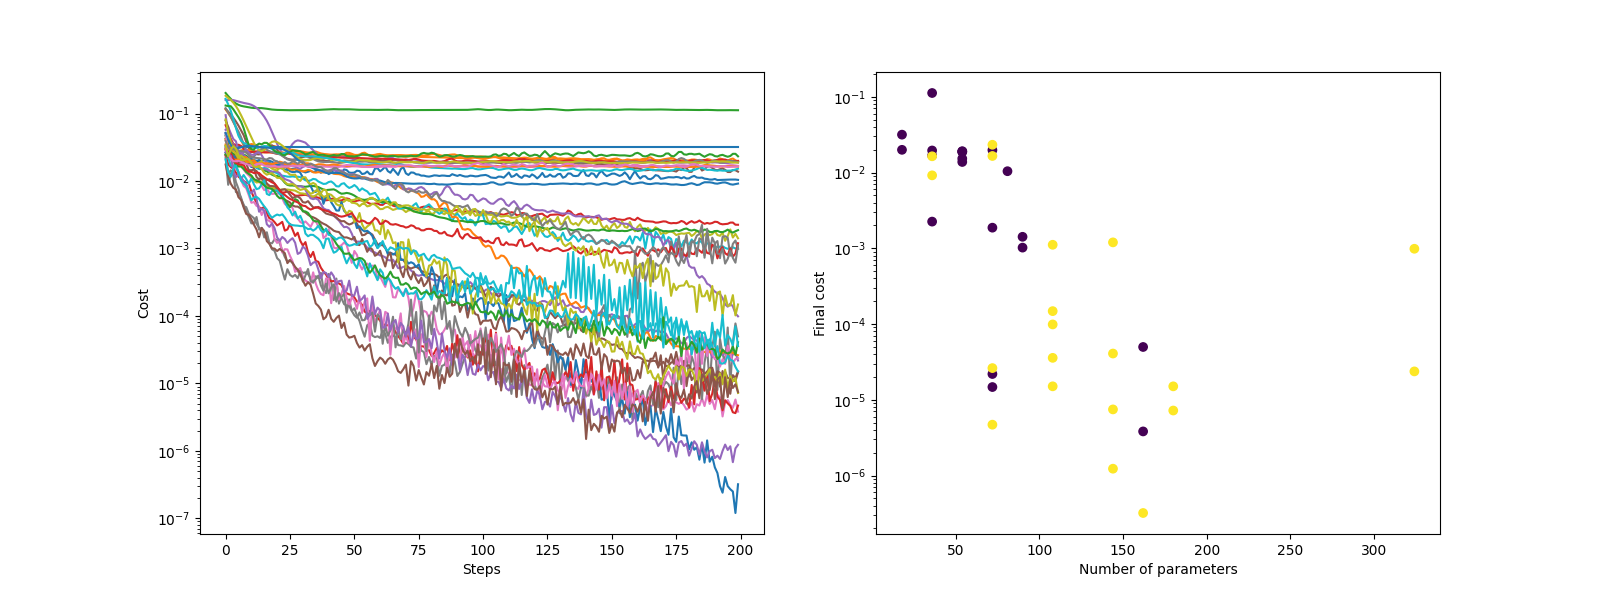

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


ax1.set_yscale('log')
for experiment in cost_history:
    steps = range(experiment["n_steps"])
    ax1.plot(steps,experiment["costs"])
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Cost")


ax2.set_yscale('log')
scatter2 = ax2.scatter(df_exp["n_params"],df_exp["final_cost"],c = df_exp["reps_color"],cmap='viridis')
ax2.set_xlabel("Number of parameters")
ax2.set_ylabel("Final cost")


cursor = mplcursors.cursor([scatter2], hover=True)

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    row = df_exp.iloc[i]
    sel.annotation.set_text(
    f"name={row['circuit_num']}\n"
    f"n_qubits={row['n_qubits']}\n"
    f"depth={row['layers']}\n"
    f"n_params={row['n_params']}\n"
    f"final_cost={row['final_cost']:.3e}\n"
    )

plt.show()

In [31]:
#load the cvs processed_results.csv as a pandas dataframe
df_frame_potential = pd.read_csv(path + "/processed_results.csv")
df_frame_potential["circuit_num"] = df_frame_potential["name"].astype(int)
df_frame_potential["anzats_reps"] = df_frame_potential["reps"].astype(int) -1
df_frame_potential["n_params_frame_potential"] = df_frame_potential["n_parameters"].astype(int)
df_frame_potential.sort_values(by=["anzats_reps","circuit_num"], inplace=True)
df_frame_potential[["n_params_frame_potential","circuit_num","anzats_reps"]].head(10)

,n_params_frame_potential,circuit_num,anzats_reps
70,24,1,0
42,24,2,0
7,34,3,0
44,34,4,0
50,58,7,0
58,58,8,0
27,12,9,0
24,40,11,0
31,40,12,0
47,34,16,0


In [39]:
#join the two dataframes df_exp and df_frame_potential on the column "circuit_num" and "anzats_reps"
df_joined = pd.merge(df_exp, df_frame_potential, on=["circuit_num", "anzats_reps"], how="inner")
#displayu only the columns "circuit_num", "n_params", "final_cost", "frame_potential"
df_joined = df_joined[["circuit_num", "n_params", "final_cost", "frame_potential","reps","n_params","n_params_frame_potential"]].sort_values(by="circuit_num")
df_joined = df_joined[df_joined["reps"]==3]

In [42]:
df_joined.sort_values(by=["frame_potential","final_cost"], inplace=True)
df_joined

,circuit_num,n_params,final_cost,frame_potential,reps,n_params,n_params_frame_potential
21,11,144,4.076000e-05,0.219809,3,144,80
15,2,72,4.690000e-06,0.251185,3,72,48
13,31,162,3.200000e-07,0.327422,3,162,108
22,12,144,1.195920e-03,0.449966,3,144,80
19,8,180,1.504000e-05,0.971632,3,180,116
25,18,108,3.575000e-05,1.094726,3,108,72
24,17,108,1.479500e-04,1.231871,3,108,68
17,4,108,1.505000e-05,1.272009,3,108,68
18,7,180,7.210000e-06,1.286866,3,180,116
23,16,108,1.111840e-03,2.377496,3,108,68


/home/tardant/Bureau/pennylane/.venv/lib/python3.12/site-packages/mplcursors/_pick_info.py:54: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  paths = scatter.__wrapped__(*args, **kwargs)


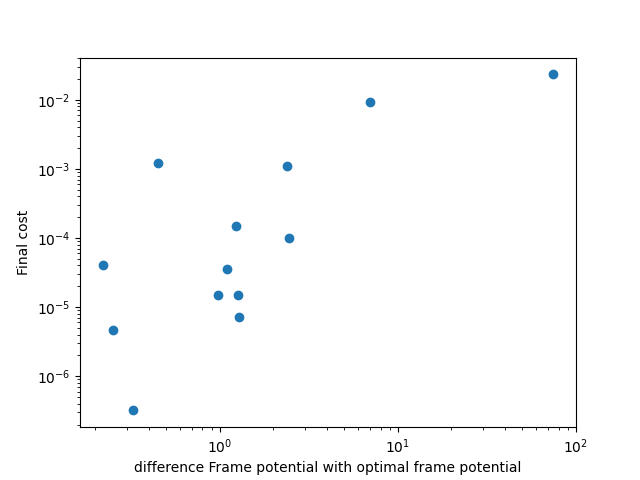

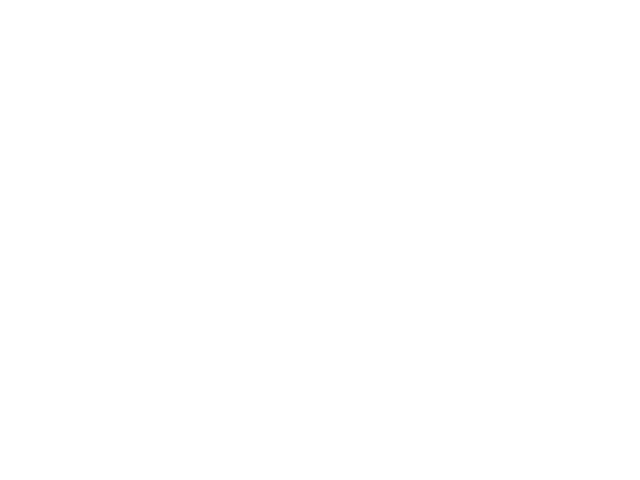

In [41]:
plt.figure()
fig, ax = plt.subplots()
ax.scatter(df_joined["frame_potential"],df_joined["final_cost"],cmap='viridis')

ax.set_xlabel("difference Frame potential with optimal frame potential")
ax.set_ylabel("Final cost")

ax.set_yscale('log')
ax.set_xscale('log')
plt.show()